PCA

Variables utilizadas

Se utilizaron únicamente variables numéricas del dataset:

Edad (age)
Tiempo de uso mensual (monthly_watch_time_mins)

Estas variables fueron seleccionadas porque el PCA solo trabaja con datos numéricos.

DATASET LIMPIO

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/dataset_limpio.csv")
df.head()

,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39,standard,805.8,Brasil,Crimen,2025-03-04,99
1,10001,37,standard,1173.4,Colombia,Crimen,2019-04-02,2
2,10002,28,Básico,401.0,Colombia,Crimen,2018-04-13,0
3,10003,43,Básico,62.4,Uruguay,Thriller,2021-01-31,0
4,10004,51,Básico,477.8,Perú,Thriller,2020-09-30,1


Escalamiento aplicado

Antes de aplicar PCA, se realizó un escalado de datos utilizando StandardScaler

In [2]:
from sklearn.preprocessing import StandardScaler

X = df[["age", "monthly_watch_time_mins"]].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Esto se hace porque:

PCA es sensible a las escalas
evita que una variable “domine” a la otra

Aplicación del PCA

In [3]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

Varianza explicada

In [4]:
print(pca.explained_variance_ratio_)

[0.50148399 0.49851601]


interpretación:

PC1 explica la mayor parte de la información
PC2 explica el resto
juntos representan el 100% de la variabilidad (en este caso con 2 variables)

Visualización 1 (PCA scatter)

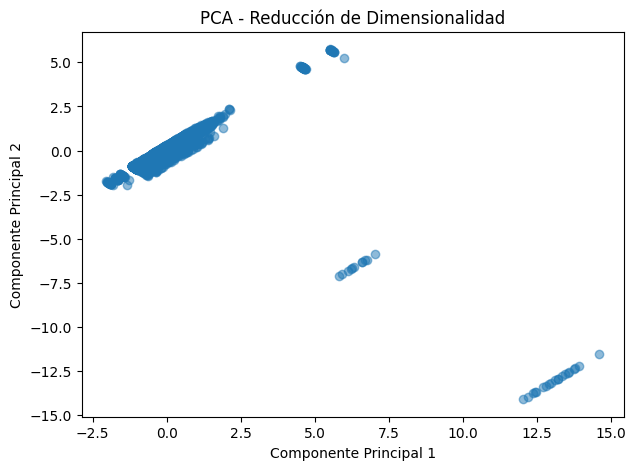

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(components[:,0], components[:,1], alpha=0.5)

plt.title("PCA - Reducción de Dimensionalidad")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.show()

El gráfico permite visualizar los datos en dos dimensiones reducidas mediante PCA, facilitando la detección de patrones.

Visualización 2 (Varianza explicada)

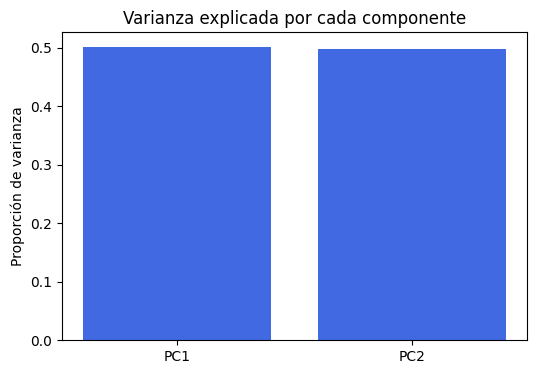

In [6]:
plt.figure(figsize=(6,4))

plt.bar(
    ["PC1", "PC2"],
    pca.explained_variance_ratio_,
    color="royalblue"
)

plt.title("Varianza explicada por cada componente")
plt.ylabel("Proporción de varianza")

plt.show()

La varianza explicada muestra cuánta información representa cada componente principal.

El PCA permitió reducir la información de las variables originales en dos componentes principales.
PC1 concentra la mayor parte de la variabilidad de los datos, mientras que PC2 aporta información complementaria.
Esto permite visualizar patrones generales de comportamiento en los usuarios de manera más simple.